In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from wordcloud import WordCloud
import matplotlib.ticker as ticker

df = pd.read_csv('spotify_data.csv')

## Introducing music genres based on scores such as danceability, valence, and energy, and showing the distribution of these genres in the dataset.

genre
Dance/Electronic    324
Hip-Hop/Rap         155
Rock                155
Jazz                115
Others               92
Pop                  85
Classical            27
Name: count, dtype: int64
Empty DataFrame
Columns: [bpm, danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveness_%, speechiness_%]
Index: []


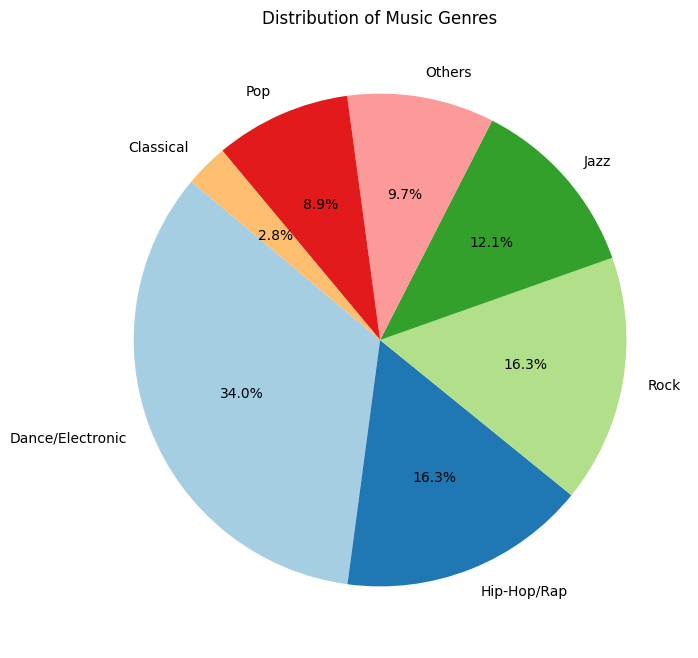

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
       'genre'],
      dtype='object')

In [ ]:
# Function to categorize genres
def categorize_genre(row):
    if (row['danceability_%'] >= 70 and row['energy_%'] >= 60 and row['bpm'] >= 80):
        return 'Dance/Electronic'
    elif (row['valence_%'] >= 60 and row['danceability_%'] >= 50 and row['energy_%'] >= 60):
        return 'Pop'
    elif (row['bpm'] <= 100 and row['danceability_%'] <= 50 and row['acousticness_%'] >= 30):
        return 'Classical'
    elif (row['bpm'] >= 120 and row['energy_%'] >= 50 and row['danceability_%'] >= 50):
        return 'Hip-Hop/Rap'
    elif (row['acousticness_%'] >= 40 and row['bpm'] >= 60 and row['danceability_%'] >= 50):
        return 'Jazz'
    elif (row['energy_%'] >= 50 and row['acousticness_%'] < 50):
        return 'Rock'
    # elif (row['instrumentalness_%'] >=0):
    #     return 'Instrumental'
    else:
        return 'Others'

# Apply the function to each row
df['genre'] = df.apply(categorize_genre, axis=1)
genre_counts = df['genre'].value_counts()

print(genre_counts)
genre_counts
classical_songs = df[df['genre'] == 'Dance']
print(classical_songs[['bpm','danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']])


# Count the occurrences of each genre
genre_counts = df['genre'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(genre_counts))))
plt.title('Distribution of Music Genres')
plt.show()


df.columns

In [ ]:
df.shape

(953, 25)